In [1]:
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from collections import defaultdict
from plotly.subplots import make_subplots
from pathlib import Path

In [2]:
# https://plotly.com/python/renderers/
import plotly.colors as pc
import plotly.io as pio

display(pio.renderers)

# svg to handle the display of more datapoints
# pio.renderers.default = "svg"

pio.renderers[pio.renderers.default].config.update(
    {
        "toImageButtonOptions": {
            "format": "svg",  # one of png, svg, jpeg, webp
            "filename": None,
            "height": None,
            "width": None,
            "scale": 1,
        },
        "displayModeBar": True,
        "modeBarButtonsToAdd": [
            "drawline",
            "drawopenpath",
            "drawclosedpath",
            "drawcircle",
            "drawrect",
            "eraseshape",
        ],
    }
)


# to also export plots
# https://stackoverflow.com/a/58718006
import plotly

plotly.offline.init_notebook_mode()

Renderers configuration
-----------------------
    Default renderer: 'plotly_mimetype'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

In [3]:
result_dir = (
    "/home/cg/NXAI/GitHub/comparison_framework/submodules/benchmark_framework/results"
)
plot_dir = Path("plots")
os.makedirs(plot_dir, exist_ok=True)

### Performance results

In [4]:
# load all results
days = [
    "*17*",
    "*18*",
    "*19*",
    "*03*",
    "*04*",
]

df_perf = pd.concat(
    [
        pd.read_json(f, lines=True)
        for d in days
        for f in Path(result_dir).glob(f"{d}.jsonl")
    ]
).reset_index(drop=True)

# keep only runs that didn't fail
df_perf = df_perf[df_perf["error"].isna()]
df_perf = df_perf.assign(**{"cc_energy_efficiency": 1 / df_perf["cc_energy_consumed"]})

# for duplicate runs, keep just one of them
idx = df_perf.groupby(["model_name", "hardware", "device", "backend"])[
    "throughput_sample__mean"
].idxmax()
df_perf = df_perf.loc[idx]

print(f"Number of rows: {len(df_perf)}")
df_perf.head()

Number of rows: 90


,model_name,backend,device,compile,hardware,batch_size,context_length,prediction_length,model_n_params,model_memory,...,gpu_power__mean,gpu_power__std,gpu_power__min,gpu_power__25%,gpu_power__50%,gpu_power__75%,gpu_power__max,error,traceback,cc_energy_efficiency
13,Datadog/Toto-Open-Base-1.0,torch,cuda,True,HPC,1,2048,32,151.31,577.19,...,100.975071,10.794097,80.353,96.160,106.735,109.174,110.962,NaN,NaN,1632.660562
105,Datadog/Toto-Open-Base-1.0,torch,cpu,True,beckhoff_c6015,1,2048,32,151.31,577.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.564820
82,Datadog/Toto-Open-Base-1.0,torch,cpu,True,beckhoff_c6025,1,2048,32,151.31,577.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,341.287353
25,Datadog/Toto-Open-Base-1.0,torch,cuda,True,dell,1,2048,32,151.31,577.19,...,19.794272,1.810723,8.856,19.276,19.907,20.524,23.114,NaN,NaN,1502.130757
41,Datadog/Toto-Open-Base-1.0,torch,cpu,True,jetson,1,2048,32,151.31,577.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,148.347745


### Fev-bench results

In [5]:
metrics = ["SQL", "MASE", "WAPE", "WQL"]

fev_model_name_map = {
    "TiRex": "NX-AI/TiRex",
    "TimesFM-2.5": "google/timesfm-2.5-200m-pytorch",
    "Chronos-2": "amazon/chronos-2",
    "Chronos-2-Synth": "autogluon/chronos-2-synth",
    "FlowState-9.1M": "ibm-research/FlowState",
    "Toto-1.0": "Datadog/Toto-Open-Base-1.0",
    "Moirai-2.0": "Salesforce/moirai-2.0-R-small",
    "TabPFN-TS": "PriorLabs/TabPFN-timeseries",
}

# load all results
df_fev = pd.concat(
    [pd.read_csv(f) for f in Path(result_dir).glob("fev/*.csv")]
).reset_index(drop=True)

# ensure all models have the same name
df_fev.replace({"model_name": fev_model_name_map}, inplace=True)

# aggregate metrics
df_fev = (
    df_fev.groupby(["model_name"])
    .agg({m: "mean" for m in metrics})
    .sort_values(metrics[0])
    .reset_index()
)

print(f"Number of rows: {len(df_fev)}")
df_fev

Number of rows: 7


,model_name,SQL,MASE,WAPE,WQL
0,amazon/chronos-2,1.280976,1.555207,0.251375,0.204975
1,google/timesfm-2.5-200m-pytorch,1.301277,1.561299,0.258303,0.211218
2,Datadog/Toto-Open-Base-1.0,1.342860,1.628129,0.276589,0.227681
3,NX-AI/TiRex,1.346058,1.620589,0.280261,0.229871
4,Salesforce/moirai-2.0-R-small,1.401614,1.676544,0.275487,0.226636
5,Chronos-Bolt,1.407661,1.702601,0.295158,0.245864
6,PriorLabs/TabPFN-timeseries,1.453382,1.769117,0.284898,0.235503


### Gift-eval results

Results scraped from the Gift-Eval leaderboard via the following code. Paste it in the browser console when viewing it.
```js
var table = document.querySelectorAll('table')[1];  // somehow need 2nd, rather than 1st table (though they appear to be the same)
var rows = Array.from(table.querySelectorAll('tr'));
var headers = Array.from(rows.shift().querySelectorAll('th, td')).map(th => th.innerText.trim());

var dict = rows.map(row => {
  const cells = Array.from(row.querySelectorAll('td'));
  return headers.reduce((obj, header, i) => {
    obj[header] = cells[i] ? cells[i].innerText.trim() : null;
    return obj;
  }, {});
});

console.dir(dict);
copy(dict); // This copies the result to your clipboard automatically!
```

and transform it appropriately and save it via Python
```python
df = pd.DataFrame(<paste-here>)
# process model names
df.insert(0, "model_name", df["model"].apply(lambda x: x.replace(" (code)", "")))
# drop unimportant columns
df.drop(columns=["T", "Test Leak.", "Replication Code", "model"], inplace=True)
# store data
df.to_csv(<results_path>, index=False)
```

In [6]:
gift_model_name_map = {
    "TiRex": "NX-AI/TiRex",
    "TimesFM-2.5": "google/timesfm-2.5-200m-pytorch",
    "Chronos-2": "amazon/chronos-2",
    "Chronos-2-Synth": "autogluon/chronos-2-synth",
    "FlowState-9.1M": "ibm-research/FlowState",
    "Toto_Open_Base_1.0": "Datadog/Toto-Open-Base-1.0",
    "Moirai2": "Salesforce/moirai-2.0-R-small",
    "PatchTST-FM-r1": "ibm-research/patchtst-fm-r1",
    "Moirai_large": "Salesforce/moirai-1.1-R-large",
    "Moirai_base": "Salesforce/moirai-1.1-R-base",
    "Moirai_small": "Salesforce/moirai-1.1-R-small",
    "Kairos_10m": "mldi-lab/Kairos_10m",
    "Kairos_23m": "mldi-lab/Kairos_23m",
    "Kairos_50m": "mldi-lab/Kairos_50m",
    "sundial_base_128m": "thuml/sundial-base-128m",
}

df_gift = pd.read_csv(Path(result_dir) / "gifteval" / "summary.csv")
df_gift.replace({"model_name": gift_model_name_map}, inplace=True)

print(f"Number of rows: {len(df_gift)}")
df_gift

Number of rows: 23


,model_name,Organization,MASE,MASE_Rank,CRPS,CRPS_Rank
0,amazon/chronos-2,AWS,0.698,14.639,0.485,15.206
1,ibm-research/patchtst-fm-r1,IBM TSFM & Rensselaer Polytechnic Institute,0.707,17.237,0.483,15.289
2,google/timesfm-2.5-200m-pytorch,Google Research,0.705,17.588,0.490,17.186
3,NX-AI/TiRex,NXAI,0.716,18.732,0.488,15.495
4,autogluon/chronos-2-synth,AWS,0.720,20.639,0.496,20.443
5,ibm-research/FlowState,IBM Research,0.726,22.619,0.502,20.144
6,granite-flowstate-r1,IBM Research,0.732,24.124,0.505,21.763
7,mldi-lab/Kairos_50m,ShanghaiTech University,0.742,24.206,0.548,32.052
8,Salesforce/moirai-2.0-R-small,Salesforce AI Research,0.728,24.515,0.516,24.381
9,Datadog/Toto-Open-Base-1.0,Datadog,0.750,26.093,0.517,23.381


### Combined results

In [7]:
df_quality = pd.merge(
    df_fev, df_gift, how="outer", on="model_name", suffixes=("_fev", "_gift")
)
df_quality

,model_name,SQL,MASE_fev,WAPE,WQL,Organization,MASE_gift,MASE_Rank,CRPS,CRPS_Rank
0,Chronos-Bolt,1.407661,1.702601,0.295158,0.245864,NaN,NaN,NaN,NaN,NaN
1,CleanTS-65M,NaN,NaN,NaN,NaN,Shandong University,0.798,30.835,0.543,26.526
2,Datadog/Toto-Open-Base-1.0,1.342860,1.628129,0.276589,0.227681,Datadog,0.750,26.093,0.517,23.381
3,NX-AI/TiRex,1.346058,1.620589,0.280261,0.229871,NXAI,0.716,18.732,0.488,15.495
4,PriorLabs/TabPFN-timeseries,1.453382,1.769117,0.284898,0.235503,NaN,NaN,NaN,NaN,NaN
5,Salesforce/moirai-1.1-R-base,NaN,NaN,NaN,NaN,Salesforce AI Research,0.901,37.722,0.610,33.247
6,Salesforce/moirai-1.1-R-large,NaN,NaN,NaN,NaN,Salesforce AI Research,0.875,37.320,0.599,33.361
7,Salesforce/moirai-1.1-R-small,NaN,NaN,NaN,NaN,Salesforce AI Research,0.946,45.773,0.650,40.186
8,Salesforce/moirai-2.0-R-small,1.401614,1.676544,0.275487,0.226636,Salesforce AI Research,0.728,24.515,0.516,24.381
9,TabPFN-TS,NaN,NaN,NaN,NaN,PriorLabs,0.771,33.680,0.544,29.907


In [8]:
df = pd.merge(df_quality[["model_name", "CRPS"]], df_perf, how="inner")

In [9]:
df["hardware"].unique()

<StringArray>
['HPC', 'beckhoff_c6015', 'beckhoff_c6025', 'dell', 'jetson', 'keba', 'rpi']
Length: 7, dtype: str

In [10]:
df.query("hardware == 'jetson'")[["model_name", "CRPS", "latency__mean"]]

,model_name,CRPS,latency__mean
4,Datadog/Toto-Open-Base-1.0,0.517,22.377330
11,NX-AI/TiRex,0.488,0.430049
14,Salesforce/moirai-1.1-R-base,0.610,8.664361
17,Salesforce/moirai-1.1-R-large,0.599,17.691405
20,Salesforce/moirai-1.1-R-small,0.650,4.733748
26,Salesforce/moirai-2.0-R-small,0.516,0.200867
33,amazon/chronos-2,0.485,0.768325
40,autogluon/chronos-2-synth,0.496,0.767630
47,google/timesfm-2.5-200m-pytorch,0.490,5.744136
54,ibm-research/FlowState,0.502,2.675788


In [11]:
edge_hardware = ["keba", "rpi", "jetson", "beckhoff_c6015", "beckhoff_c6025"]
df = df.assign(
    **{
        "is_edge_hardware": df["hardware"].isin(edge_hardware),
        "ours": df["model_name"] == "NX-AI/TiRex",
    }
)
df = df.assign(
    **{
        "competition": ~df["ours"],
        "method": df["ours"].apply(lambda x: "Ours" if x else "Competitors"),
    }
)

# {m: m for m in df["model_name"].unique().tolist()}
clear_model_map = {
    "Datadog/Toto-Open-Base-1.0": "Datadog/Toto",
    "NX-AI/TiRex": "NX-AI/TiRex",
    "Salesforce/moirai-2.0-R-small": "Salesforce/Moirai-2",
    "Salesforce/moirai-1.1-R-large": "Salesforce/Moirai-1.1-large",
    "Salesforce/moirai-1.1-R-base": "Salesforce/Moirai-1.1-base",
    "Salesforce/moirai-1.1-R-small": "Salesforce/Moirai-1.1-small",
    "amazon/chronos-2": "Amazon/Chronos-2",
    "autogluon/chronos-2-synth": "Amazon/Chronos-2-Synth",
    "google/timesfm-2.5-200m-pytorch": "Google/TimesFM-2.5",
    "ibm-research/FlowState": "IBM-Research/FlowState",
    "ibm-research/patchtst-fm-r1": "IBM-Research/PatchTST-FM",
    "mldi-lab/Kairos_10m": "ShanghaiTech/Kairos-10m",
    "mldi-lab/Kairos_23m": "ShanghaiTech/Kairos-23m",
    "mldi-lab/Kairos_50m": "ShanghaiTech/Kairos-50m",
    "thuml/sundial-base-128m": "Tsinghua/Sundial",
}

# {h: h for h in df["hardware"].unique().tolist()}
clear_hardware_map = {
    "keba": "KEBA PLC",
    "HPC": "HPC",
    "dell": "Dell Workstation",
    "rpi": "Raspberry Pi",
    "jetson": "NVIDIA Jetson",
    "beckhoff_c6015": "Beckhoff C6015",
    "beckhoff_c6025": "Beckhoff C6025",
}

_ = df.replace(
    {
        "model_name": clear_model_map,
        "hardware": clear_hardware_map,
    },
    inplace=True,
)
edge_hardware = [clear_hardware_map[hw] for hw in edge_hardware]

df.head()

,model_name,CRPS,backend,device,compile,hardware,batch_size,context_length,prediction_length,model_n_params,...,gpu_power__50%,gpu_power__75%,gpu_power__max,error,traceback,cc_energy_efficiency,is_edge_hardware,ours,competition,method
0,Datadog/Toto,0.517,torch,cuda,True,HPC,1,2048,32,151.31,...,106.735,109.174,110.962,NaN,NaN,1632.660562,False,False,True,Competitors
1,Datadog/Toto,0.517,torch,cpu,True,Beckhoff C6015,1,2048,32,151.31,...,NaN,NaN,NaN,NaN,NaN,93.564820,True,False,True,Competitors
2,Datadog/Toto,0.517,torch,cpu,True,Beckhoff C6025,1,2048,32,151.31,...,NaN,NaN,NaN,NaN,NaN,341.287353,True,False,True,Competitors
3,Datadog/Toto,0.517,torch,cuda,True,Dell Workstation,1,2048,32,151.31,...,19.907,20.524,23.114,NaN,NaN,1502.130757,False,False,True,Competitors
4,Datadog/Toto,0.517,torch,cpu,True,NVIDIA Jetson,1,2048,32,151.31,...,NaN,NaN,NaN,NaN,NaN,148.347745,True,False,True,Competitors


In [12]:
df["hardware"].unique()

<StringArray>
[             'HPC',   'Beckhoff C6015',   'Beckhoff C6025',
 'Dell Workstation',    'NVIDIA Jetson',         'KEBA PLC',
     'Raspberry Pi']
Length: 7, dtype: str

## Notes

- custom CUDA kernel for TiRex does not yet run on Blackwell architecture
- energy consumption may not be very precise (only precise for Intel CPUs with RAPL enabled)

## Graphics

In [13]:
# see https://plotly.com/python/marker-style/
import plotly.graph_objects as go
from plotly.validator_cache import ValidatorCache

In [14]:
def get_symbol_shapes():
    SymbolValidator = ValidatorCache.get_validator("scatter.marker", "symbol")
    raw_symbols = SymbolValidator.values
    value_symbol_map = dict(
        sorted(
            (raw_symbols[i], raw_symbols[i + 2]) for i in range(0, len(raw_symbols), 3)
        )
    )
    all_symbols = list(value_symbol_map.values())
    symbol_shapes = []
    for s in all_symbols:
        s = s.replace("-open", "").replace("-dot", "")
        if s not in symbol_shapes:
            symbol_shapes.append(s)
    return symbol_shapes


def get_symbol_types():
    return [None, "-open", "-dot", "-open-dot"]

In [15]:
def pareto_front(df: pd.DataFrame, x: str, y: str, col: str, to_exclude: list[str]):
    # only for those that we want to consider
    df = df[~df[col].isin(to_exclude)]

    front_x, front_y = [], []
    best_y = float("inf")
    best_x = -float("inf")
    # best_x = 0
    for _, (xi, yi) in df[[x, y]].sort_values(by=[x, y]).iterrows():
        if yi < best_y and xi > best_x:
            front_x.append(xi)
            front_y.append(yi)
            best_x = xi
            best_y = yi

    return front_x, front_y

In [16]:
def create_scatter_plot(
    df: pd.DataFrame,
    x: str,
    y: str,
    title: str = None,
    column_color: str = None,
    column_symbol_shape: str = None,
    column_symbol_type: str = None,
    column_marker_text: str = None,
    marker_text_position: str = "top center",
    line_width: int = 0,
    marker_size: int = 5,
    height: int = None,
    width: int = None,
    log_x: bool = False,
    log_y: bool = False,
    clear_name_map: dict = None,
    column_pareto_front: str = None,
    front_exclude_column: str = None,
    front_exclude_values: list[any] = None,
    reverse_color_order: bool = False,
    reverse_symbol_shape_order: bool = False,
    reverse_symbol_type_order: bool = False,
    symbol_type_map: dict = None,
):
    if clear_name_map is None:
        clear_name_map = {}

    available_colors = px.colors.qualitative.Dark24.copy()
    symbol_shapes = get_symbol_shapes()
    symbol_types = get_symbol_types()

    # defaults
    color = available_colors[0]
    symbol_shape = symbol_shapes[0]
    symbol_type = ""

    color_map = {}
    if column_color is not None:
        if column_color in df.columns:
            data_color = df[column_color]
            unique_values = sorted(list(data_color.unique()))
            if reverse_color_order:
                unique_values = unique_values[::-1]
            color_map = {v: c for c, v in zip(available_colors, unique_values)}
            if len(unique_values) > len(color_map):
                raise ValueError(
                    f"Data has more unique values ({len(unique_values)}) than colors are available ({len(available_colors)})"
                )
            color = data_color.replace(color_map)
        else:
            # default to color value being directly provided (single value for all)
            color = column_color

    symbol_shape_map = {}
    if column_symbol_shape is not None:
        if column_symbol_shape in df.columns:
            data_symbol_shape = df[column_symbol_shape]
            unique_values = sorted(list(data_symbol_shape.unique()))
            if reverse_symbol_shape_order:
                unique_values = unique_values[::-1]
            symbol_shape_map = {v: s for s, v in zip(symbol_shapes, unique_values)}
            if len(unique_values) > len(symbol_shape_map):
                raise ValueError(
                    f"Data has more unique values ({len(unique_values)}) than shapes are available ({len(symbols)})"
                )
            symbol_shape = data_symbol_shape.replace(symbol_shape_map)
        else:
            # default to symbol being directly provided (single value for all)
            symbol_shape = column_symbol

    if column_symbol_type is not None:
        if column_symbol_type in df.columns:
            data_symbol_type = df[column_symbol_type]
            unique_values = sorted(list(data_symbol_type.unique()))
            if symbol_type_map is None:
                if reverse_symbol_type_order:
                    unique_values = unique_values[::-1]
                symbol_type_map = {
                    v: s or "" for s, v in zip(symbol_types, unique_values)
                }
            if len(unique_values) > len(symbol_type_map):
                raise ValueError(
                    f"Data has more unique values ({len(unique_values)}) than symbol types are available ({len(symbol_types)})"
                )
            symbol_type = data_symbol_type.replace(symbol_type_map)
        else:
            symbol_type_map = {}
            # default to type being directly provided (single value for all)
            symbol_type = column_symbol_type
    else:
        symbol_type_map = {}

    # join symbol shape and type
    symbol = symbol_shape + symbol_type

    hover_template = (
        clear_name_map.get(x, x)
        + ": %{x}<br>"
        + clear_name_map.get(y, y)
        + ": %{y}<br>"
    )
    custom_data = [[None] * len(df)] * 3
    if column_color in df.columns:
        custom_data[0] = df[column_color]
        hover_template += (
            clear_name_map.get(column_color, column_color) + ": %{customdata[0]}<br>"
        )
    if column_symbol_shape in df.columns:
        custom_data[1] = df[column_symbol_shape]
        hover_template += (
            clear_name_map.get(column_symbol_shape, column_symbol_shape)
            + ": %{customdata[1]}<br>"
        )
    if column_symbol_type in df.columns:
        custom_data[2] = df[column_symbol_type]
        hover_template += (
            clear_name_map.get(column_symbol_type, column_symbol_type)
            + ": %{customdata[2]}<br>"
        )
    hover_template += "<extra></extra>"
    custom_data = list(zip(*custom_data))

    main_trace = go.Scatter(
        x=df[x],
        y=df[y],
        mode="markers+text" if column_marker_text is not None else "markers",
        text=df[column_marker_text] if column_marker_text is not None else None,
        textposition=marker_text_position,
        marker={
            "color": color,
            "symbol": symbol,
            "line_width": line_width,
            "size": marker_size,
        },
        showlegend=False,
        customdata=custom_data,
        hovertemplate=hover_template,
    )

    # range is the same for all plots
    x_max = df[x].max()
    y_max = df[y].max()
    x_min = df[x].min()
    y_min = df[y].min()

    x_span = x_max - x_min
    y_span = y_max - y_min

    perc = 0.05
    x_margin = x_span * perc
    y_margin = y_span * perc
    x_range = [x_min - x_margin, x_max + x_margin]
    y_range = [y_min - y_margin, y_max + y_margin]

    if log_x:
        xl_min, xl_max = np.log10(x_min), np.log10(x_max)
        x_margin_exp = np.abs(xl_max - xl_min) * perc
        x_range = [
            np.power(10, xl_min - x_margin_exp),
            np.power(10, xl_max + x_margin_exp),
        ]
    if log_y:
        yl_min, yl_max = np.log10(y_min), np.log10(y_max)
        y_margin_exp = np.abs(yl_max - yl_min) * perc
        y_range = [
            np.power(10, yl_min - y_margin_exp),
            np.power(10, yl_max + y_margin_exp),
        ]

    x_pareto = x_range[1]
    y_pareto = y_range[1]

    pareto_traces = []
    if column_pareto_front is not None:
        for v, grp in df.groupby(by=column_pareto_front):
            pareto_color = (
                color_map[v] if column_pareto_front == column_color else "#222222"
            )

            def hex_to_rgba(hex_color, alpha):
                r, g, b = pc.hex_to_rgb(hex_color)
                return f"rgba({r}, {g}, {b}, {alpha})"

            pareto_fill_color = hex_to_rgba(pareto_color, 0.1)
            pareto_border_color = hex_to_rgba(pareto_color, 0.7)

            front_x, front_y = pareto_front(
                grp, x=x, y=y, col=front_exclude_column, to_exclude=front_exclude_values
            )
            if len(front_x) == 0 or len(front_y) == 0:
                continue
            x_min_grp = min(front_x)
            y_min_grp = min(front_y)

            pareto_traces.append(
                go.Scatter(
                    x=front_x,
                    y=front_y,
                    mode="lines",
                    line=dict(
                        color=pareto_border_color,
                        width=1,
                        dash="solid",
                    ),
                    # showlegend=False,
                    name=v,
                    legendgroup="pareto",
                    legendgrouptitle_text="Pareto Front",
                )
            )

            x_pareto_coords = [x_min_grp, x_pareto, x_pareto]
            y_pareto_coords = [y_pareto, y_pareto, y_min_grp]
            pareto_traces.append(
                go.Scatter(
                    x=x_pareto_coords,
                    y=y_pareto_coords,
                    mode="lines",
                    line_width=0,
                    fill="tonexty",
                    fillcolor=pareto_fill_color,
                    hoverinfo="none",
                    showlegend=False,
                    # name=v,
                    # legendgroup="pareto",
                    # legendgrouptitle_text="Pareto Front",
                )
            )

    fig = go.Figure(data=[*pareto_traces, main_trace])

    default_color = color if isinstance(color, str) else "gray"
    default_symbol_shape = (
        symbol_shape if isinstance(symbol_shape, str) else symbol_shape.iloc[0]
    )
    default_symbol_type = (
        symbol_type if isinstance(symbol_type, str) else symbol_type.iloc[0]
    )

    # create legend for color
    color_title = clear_name_map.get(column_color, column_color)
    for k, c in color_map.items():
        fig.add_trace(
            go.Scatter(
                x=[None],
                y=[None],
                mode="markers",
                name=f"{k}",
                legendgroup=color_title,
                legendgrouptitle_text=color_title,
                marker={
                    "color": c,
                    "symbol": default_symbol_shape + default_symbol_type,
                    "line_width": line_width,
                    "size": marker_size,
                },
            )
        )

    # create legend for symbol shape
    shape_title = clear_name_map.get(column_symbol_shape, column_symbol_shape)
    for k, s in symbol_shape_map.items():
        fig.add_trace(
            go.Scatter(
                x=[None],
                y=[None],
                mode="markers",
                name=f"{k}",
                legendgroup=shape_title,
                legendgrouptitle_text=shape_title,
                marker={
                    "color": default_color,
                    "symbol": s + default_symbol_type,
                    "line_width": line_width,
                    "size": marker_size,
                },
            )
        )

    # create legend for symbol fill type
    type_title = clear_name_map.get(column_symbol_type, column_symbol_type)
    for k, t in symbol_type_map.items():
        fig.add_trace(
            go.Scatter(
                x=[None],
                y=[None],
                mode="markers",
                name=f"{k}",
                legendgroup=type_title,
                legendgrouptitle_text=type_title,
                marker={
                    "color": default_color,
                    "symbol": default_symbol_shape + t,
                    # for symbol type, we need at least some line width to be able to show the symbol
                    "line_width": max(line_width, 2),
                    "size": marker_size,
                },
            )
        )

    fig.update_xaxes(title_text=clear_name_map.get(x, x))
    if log_x:
        fig.update_xaxes(type="log")
    fig.update_yaxes(title_text=clear_name_map.get(y, y))
    if log_y:
        fig.update_yaxes(type="log")

    fig.update_layout(
        height=height,
        width=width,
        title=title,
        xaxis=dict(range=x_range, autorange=True),
        yaxis=dict(range=y_range, autorange=True),
    )

    return fig

In [ ]:
def save_fig(fig, label):
    # if this throws a BrowserFailedError, check out installation guide from kaleido
    # https://github.com/plotly/Kaleido#installation
    # you might need to run "kaleido_get_chrome" command in terminal
    fig.write_image(plot_dir / f"{label}.png")
    fig.write_image(plot_dir / f"{label}.svg")

In [ ]:
clear_name_map = {
    "cc_energy_consumed": "Consumed Energy [kWh] (↓)",
    "cc_energy_efficiency": "Energy Efficiency [1/W] (↑)",
    "SQL": "SQL (↓)",
    "latency__mean": "Latency [s] (↓)",
    "CRPS": "CRPS (↓)",
    "model_name": "Model",
    "hardware": "Hardware",
    "is_edge_hardware": "Edge Hardware",
    "ours": "Our Technology",
    "model_n_params": "Number of Parameters [M] (↓)",
    "throughput_batch__mean": "Throughput [1/s] (↑)",
    "method": "Method",
}

In [19]:
df.query("is_edge_hardware")["hardware"].unique()

<StringArray>
['Beckhoff C6015', 'Beckhoff C6025', 'NVIDIA Jetson', 'KEBA PLC',
 'Raspberry Pi']
Length: 5, dtype: str

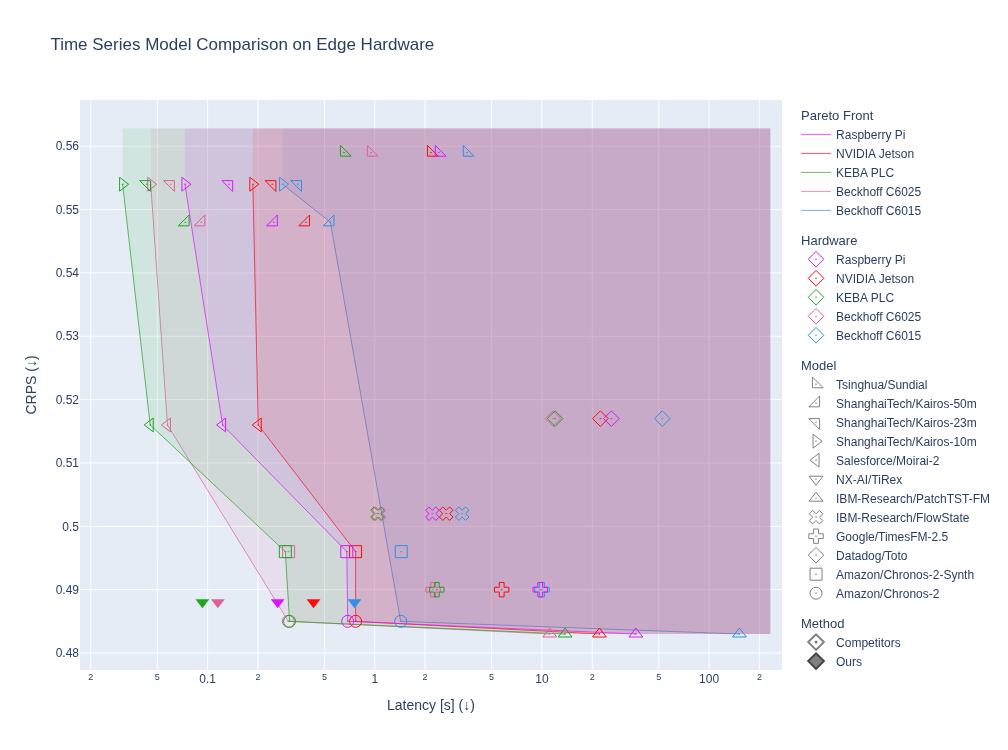

In [20]:
fig = create_scatter_plot(
    df.query("is_edge_hardware").query(
        '~model_name.str.startswith("Salesforce/Moirai-1.1")'
    ),
    x="latency__mean",
    y="CRPS",
    column_color="hardware",
    column_symbol_shape="model_name",
    column_symbol_type="method",
    symbol_type_map={"Ours": "", "Competitors": "-open-dot"},
    clear_name_map=clear_name_map,
    marker_size=12,
    width=1000,
    height=750,
    log_x=True,
    column_pareto_front="hardware",
    front_exclude_column="model_name",
    front_exclude_values=["NX-AI/TiRex"],
    title="Time Series Model Comparison on Edge Hardware",
    reverse_symbol_type_order=True,
)
save_fig(fig, "pareto_all_CRPS_latency")
fig.show()

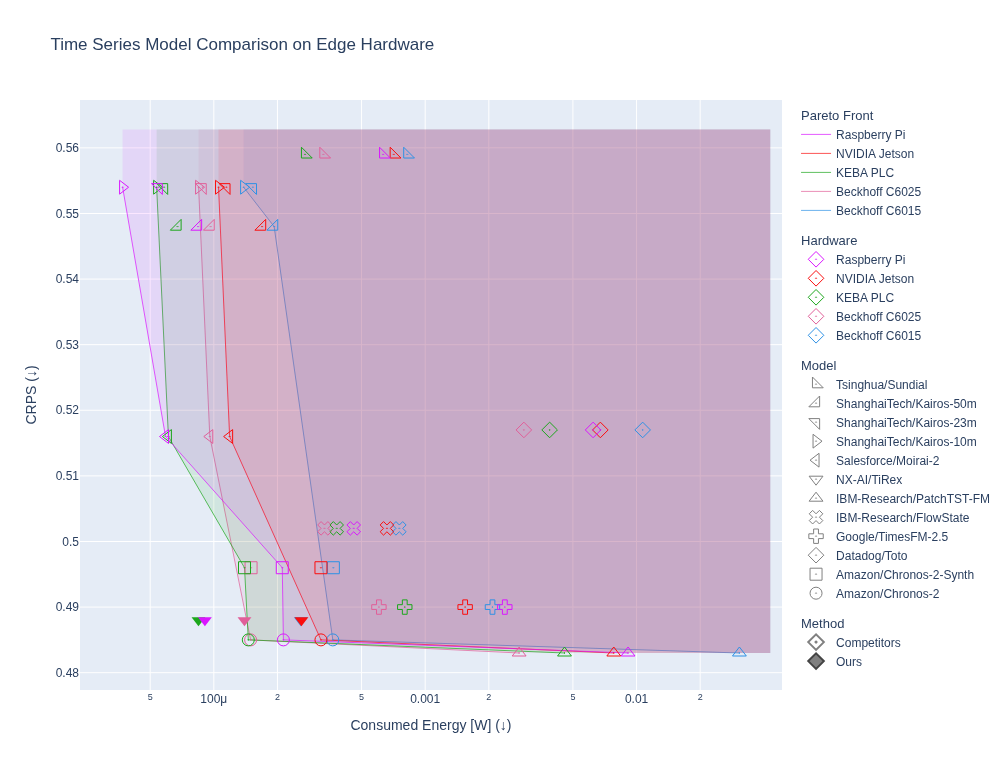

In [21]:
fig = create_scatter_plot(
    df.query("is_edge_hardware").query(
        '~model_name.str.startswith("Salesforce/Moirai-1.1")'
    ),
    x="cc_energy_consumed",
    y="CRPS",
    column_color="hardware",
    column_symbol_shape="model_name",
    column_symbol_type="method",
    symbol_type_map={"Ours": "", "Competitors": "-open-dot"},
    clear_name_map=clear_name_map,
    marker_size=12,
    width=1000,
    height=770,
    log_x=True,
    column_pareto_front="hardware",
    front_exclude_column="model_name",
    front_exclude_values=["NX-AI/TiRex"],
    title="Time Series Model Comparison on Edge Hardware",
    reverse_symbol_type_order=True,
)
fig.show()
save_fig(fig, "pareto_all_CRPS_energy")

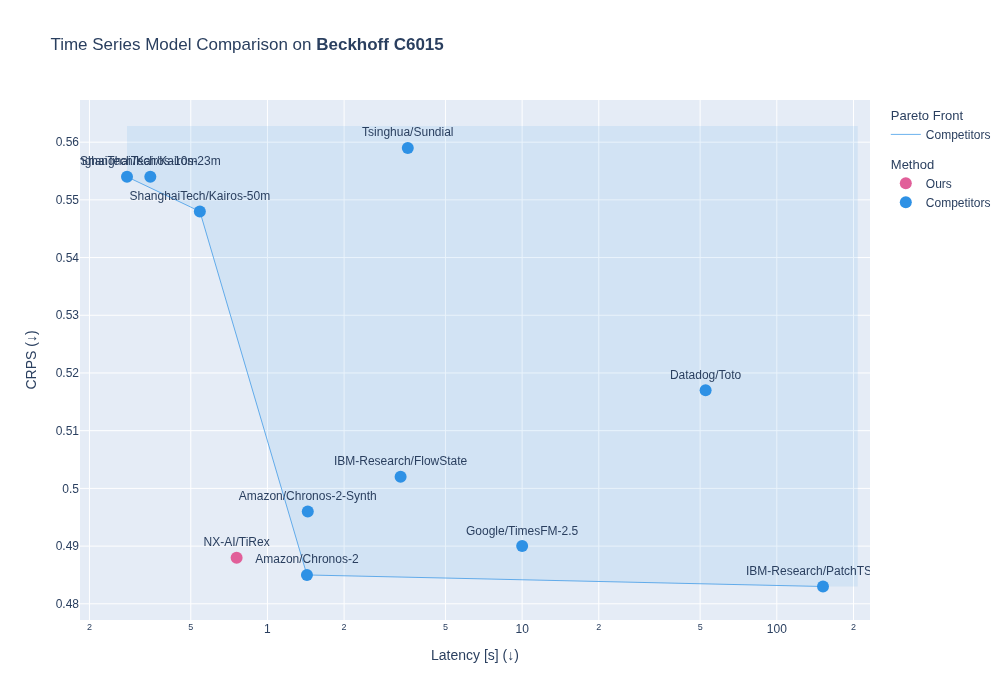

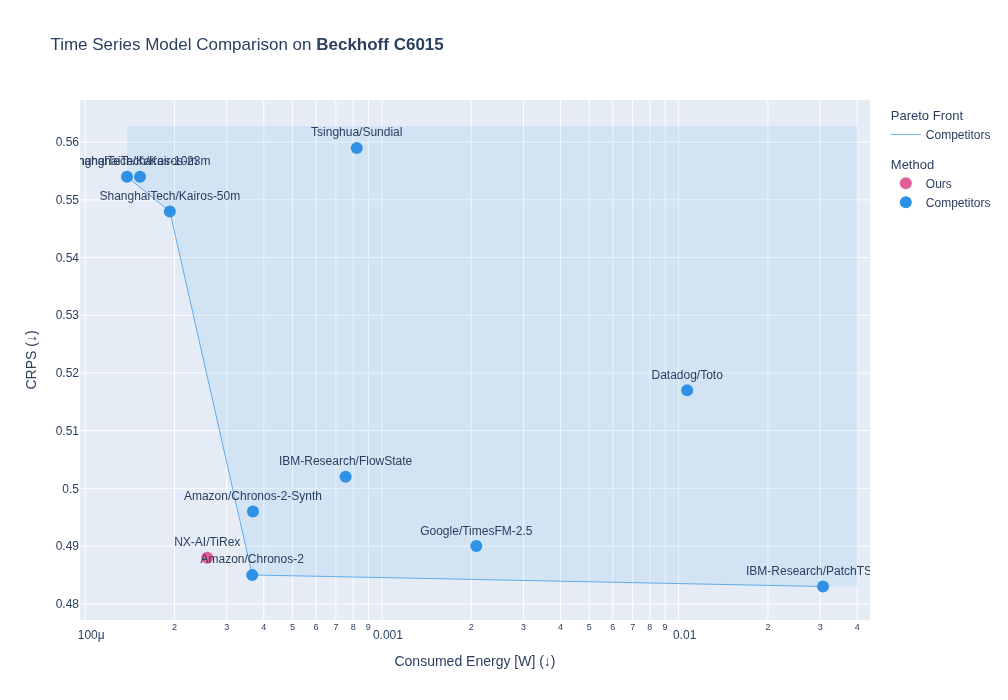

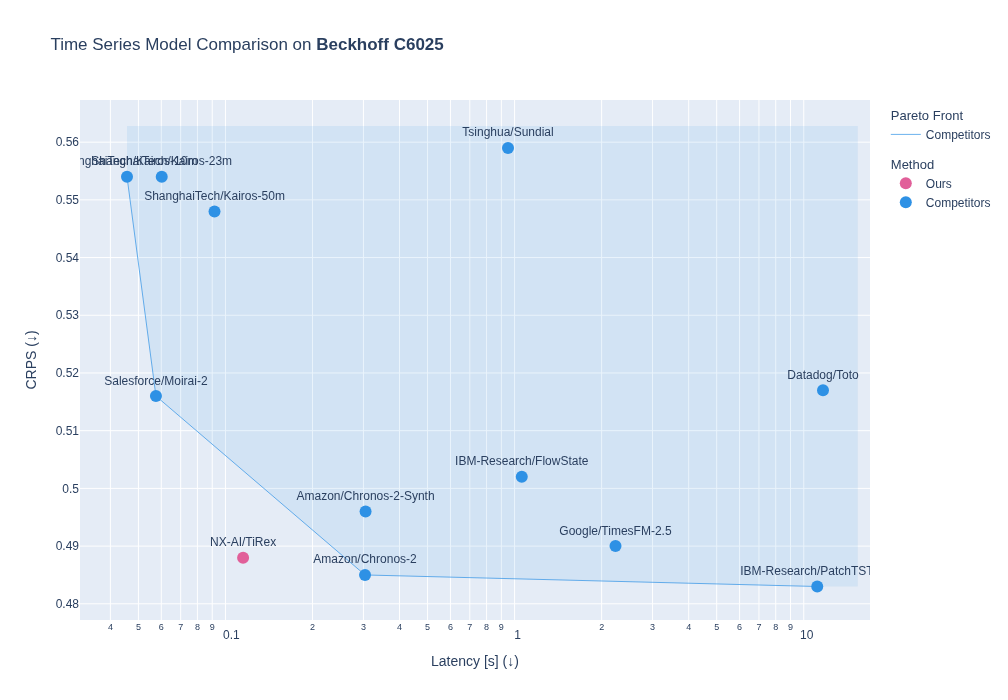

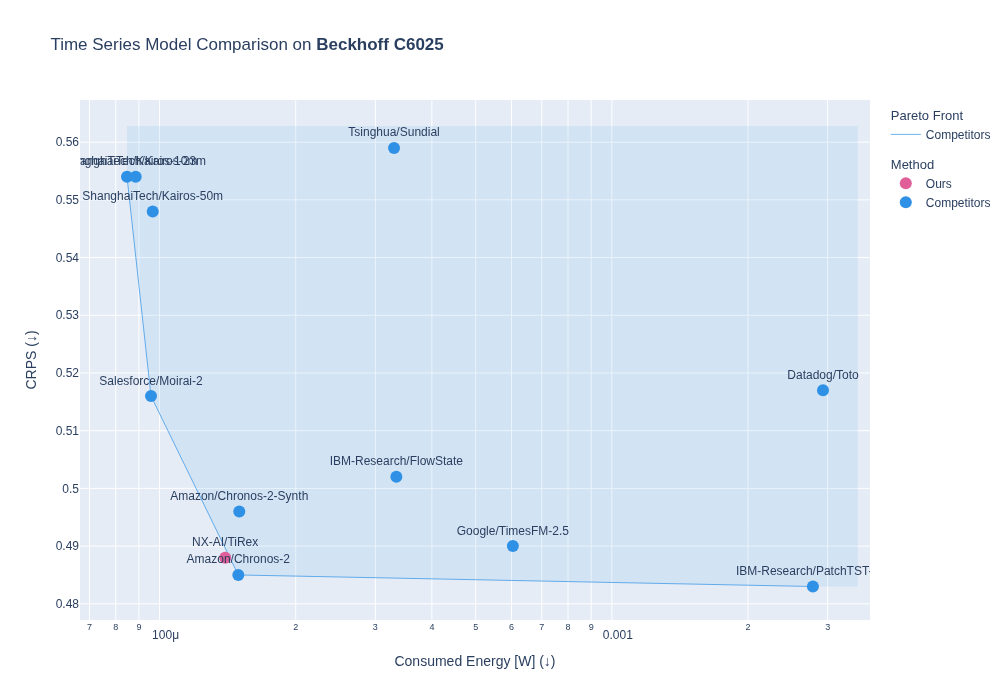

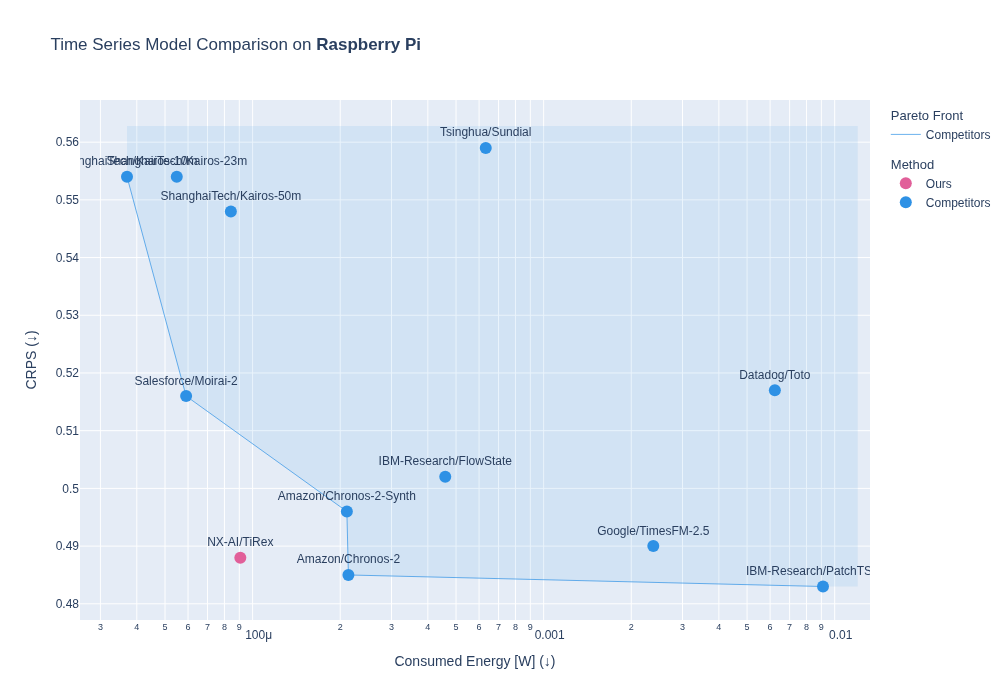

In [22]:
for hw, grp in df.query("is_edge_hardware").groupby("hardware"):
    for metric in ["latency__mean", "cc_energy_consumed"]:
        fig = create_scatter_plot(
            grp.query('~model_name.str.startswith("Salesforce/Moirai-1.1")'),
            x=metric,
            y="CRPS",
            column_color="method",
            clear_name_map=clear_name_map,
            marker_size=12,
            width=1000,
            height=700,
            log_x=True,
            column_pareto_front="method",
            front_exclude_column="model_name",
            front_exclude_values=["NX-AI/TiRex"],
            title=f"Time Series Model Comparison on <b>{hw}</b>",
            column_marker_text="model_name",
            marker_text_position="top center",
        )
        fig.show()
        save_fig(fig, f"pareto_{hw}_CRPS_{metric}")

## Plot for EIC

In [23]:
higher_precision_columns = ["CRPS"]
quality_metric_cols = ["CRPS"]
performance_metric_cols = [
    "throughput_batch__mean",
    "latency__mean",
    "cc_energy_consumed",
    "cc_energy_efficiency",
]
higher_is_better = [True, False, False, True]
metric_better_map = {m: b for m, b in zip(performance_metric_cols, higher_is_better)}

metrics_cols = quality_metric_cols + performance_metric_cols

selected_models = [
    "NX-AI/TiRex",
    "Amazon/Chronos-2",
    "Google/TimesFM-2.5",
    "IBM-Research/PatchTST-FM",
]

normal_precision = 2
high_precision = 3
raw_precision = 5

round_settings = {
    c: high_precision if c in higher_precision_columns else normal_precision
    for c in metrics_cols
}

round_settings_raw = {
    "CRPS": 3,
    "throughput_batch__mean": 2,
    "latency__mean": 2,
    "cc_energy_consumed": 5,
    "cc_energy_efficiency": 5,
}

In [ ]:
agg = {}
for hw in edge_hardware:
    print("\nHardware:", hw)

    df_eic = (
        df.query("model_name in @selected_models")
        .query("hardware == @hw")[["model_name", *metrics_cols]]
        .reset_index(drop=True)
    )

    display(
        df_eic.round(round_settings_raw).rename(
            columns={
                "cc_energy_consumed": "Consumed Energy [kWh] (↓)",
                "cc_energy_efficiency": "Energy Efficiency [1/W] (↑)",
                "latency__mean": "Latency [s] (↓)",
                "CRPS": "CRPS (↓)",
                "model_name": "Model",
                "throughput_batch__mean": "Throughput [1/s] (↑)",
            }
        )
    )

    df_ratio = (
        df_eic[metrics_cols]
        / df_eic.query("model_name == 'NX-AI/TiRex'")[metrics_cols].iloc[0]
        * 100
    )
    df_eic_r = df_eic[["model_name"]].join(df_ratio)

    df_factor = (
        df_eic[metrics_cols]
        / df_eic.query("model_name == 'NX-AI/TiRex'")[metrics_cols].iloc[0]
    )
    df_eic_f = df_eic[["model_name"]].join(df_factor).set_index("model_name")

    tf = df_eic_f.query("model_name == 'NX-AI/TiRex'")
    ntf = df_eic_f.query("model_name != 'NX-AI/TiRex'")

    ntff = (ntf - 1).round(round_settings).astype(str) + "x"
    # add '+' sign
    ntff = ntff.map(lambda x: x if x.startswith("-") else f"+{x}")

    display(
        pd.concat([tf, ntff])
        .reset_index()
        .rename(
            columns={
                "cc_energy_consumed": "Consumed Energy (↓)",
                "cc_energy_efficiency": "Energy Efficiency (↑)",
                "latency__mean": "Latency (↓)",
                "CRPS": "CRPS (↓)",
                "model_name": "Model",
                "throughput_batch__mean": "Throughput (↑)",
            }
        )
    )

    agg[hw] = (df_eic, df_eic_r)


Hardware: KEBA PLC


,Model,CRPS (↓),Throughput [1/s] (↑),Latency [s] (↓),Consumed Energy [W] (↓),Energy Efficiency [1/W] (↑)
0,NX-AI/TiRex,0.488,10.75,0.09,0.00008,11818.67563
1,Amazon/Chronos-2,0.485,3.24,0.31,0.00015,6868.14511
2,Google/TimesFM-2.5,0.490,0.43,2.35,0.00080,1249.17389
3,IBM-Research/PatchTST-FM,0.483,0.07,13.76,0.00456,219.24089


,Model,CRPS (↓),Throughput (↑),Latency (↓),Consumed Energy (↓),Energy Efficiency (↑)
0,NX-AI/TiRex,1.0,1.0,1.0,1.0,1.0
1,Amazon/Chronos-2,-0.006x,-0.7x,+2.32x,+0.72x,-0.42x
2,Google/TimesFM-2.5,+0.004x,-0.96x,+24.26x,+8.46x,-0.89x
3,IBM-Research/PatchTST-FM,-0.01x,-0.99x,+146.81x,+52.91x,-0.98x



Hardware: Raspberry Pi


,Model,CRPS (↓),Throughput [1/s] (↑),Latency [s] (↓),Consumed Energy [W] (↓),Energy Efficiency [1/W] (↑)
0,NX-AI/TiRex,0.488,3.83,0.26,0.00009,11020.27987
1,Amazon/Chronos-2,0.485,1.45,0.69,0.00021,4686.43468
2,Google/TimesFM-2.5,0.490,0.10,9.77,0.00238,420.02264
3,IBM-Research/PatchTST-FM,0.483,0.03,36.47,0.00912,109.69073


...

,Model,CRPS (↓),Throughput [1/s] (↑),Latency [s] (↓),Consumed Energy [W] (↓),Energy Efficiency [1/W] (↑)
0,NX-AI/TiRex,0.488,1.34,0.76,0.00026,3877.65238
1,Amazon/Chronos-2,0.485,0.71,1.43,0.00037,2735.62927
2,Google/TimesFM-2.5,0.490,0.10,10.00,0.00208,480.56392
3,IBM-Research/PatchTST-FM,0.483,0.01,151.84,0.03066,32.61565


,Model,CRPS (↓),Throughput (↑),Latency (↓),Consumed Energy (↓),Energy Efficiency (↑)
0,NX-AI/TiRex,1.0,1.0,1.0,1.0,1.0
1,Amazon/Chronos-2,-0.006x,-0.47x,+0.89x,+0.42x,-0.29x
2,Google/TimesFM-2.5,+0.004x,-0.93x,+12.22x,+7.07x,-0.88x
3,IBM-Research/PatchTST-FM,-0.01x,-1.0x,+199.67x,+117.89x,-0.99x



Hardware: Beckhoff C6025


,Model,CRPS (↓),Throughput [1/s] (↑),Latency [s] (↓),Consumed Energy [W] (↓),Energy Efficiency [1/W] (↑)
0,NX-AI/TiRex,0.488,8.86,0.12,0.00014,7161.05717
1,Amazon/Chronos-2,0.485,3.31,0.30,0.00015,6698.45976
2,Google/TimesFM-2.5,0.490,0.45,2.23,0.00060,1655.32082
3,IBM-Research/PatchTST-FM,0.483,0.09,11.14,0.00278,359.28138


,Model,CRPS (↓),Throughput (↑),Latency (↓),Consumed Energy (↓),Energy Efficiency (↑)
0,NX-AI/TiRex,1.0,1.0,1.0,1.0,1.0
1,Amazon/Chronos-2,-0.006x,-0.63x,+1.64x,+0.07x,-0.06x
2,Google/TimesFM-2.5,+0.004x,-0.95x,+18.4x,+3.33x,-0.77x
3,IBM-Research/PatchTST-FM,-0.01x,-0.99x,+95.75x,+18.93x,-0.95x


In [25]:
def order_models_by_ours(models):
    return sorted([m for m in models if "NX-AI" in m]) + sorted(
        [m for m in models if "NX-AI" not in m]
    )

In [26]:
color_map = {True: "#00a08b", False: "#b3b3b3"}
method_color_map = {"Ours": "#00a08b", "Competitors": "#b3b3b3"}

df_melted = df.melt(
    id_vars=["model_name", "hardware", "method"],
    value_vars=quality_metric_cols + performance_metric_cols,
    var_name="metric",
    value_name="val",
)

for hw in edge_hardware:
    fig = px.bar(
        df_melted.query("hardware == @hw & model_name in @selected_models"),
        x="model_name",
        y="val",
        facet_col="metric",
        facet_col_spacing=0.1,
        color="method",
        color_discrete_map=method_color_map,
        category_orders={"model_name": order_models_by_ours(selected_models)},
        title=hw,
        labels=clear_name_map,
    )
    fig.update_yaxes(matches=None, showticklabels=True, title_text="")
    fig.update_xaxes(type="category")
    fig.update_layout(
        bargap=0.1,
        showlegend=True,
        height=500,
        width=1500,
    )
    fig.for_each_annotation(
        lambda a: a.update(text=clear_name_map.get(a.text.split("=")[-1]))
    )
    fig.show()
    save_fig(fig, f"bars_{hw}")

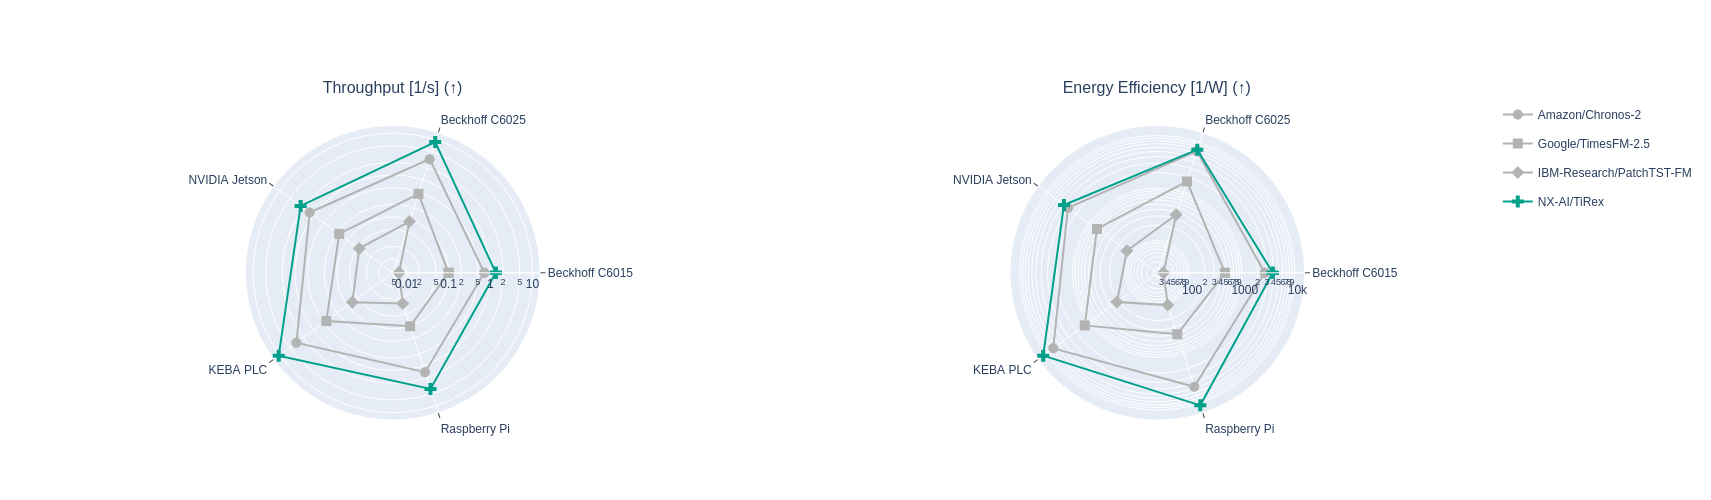

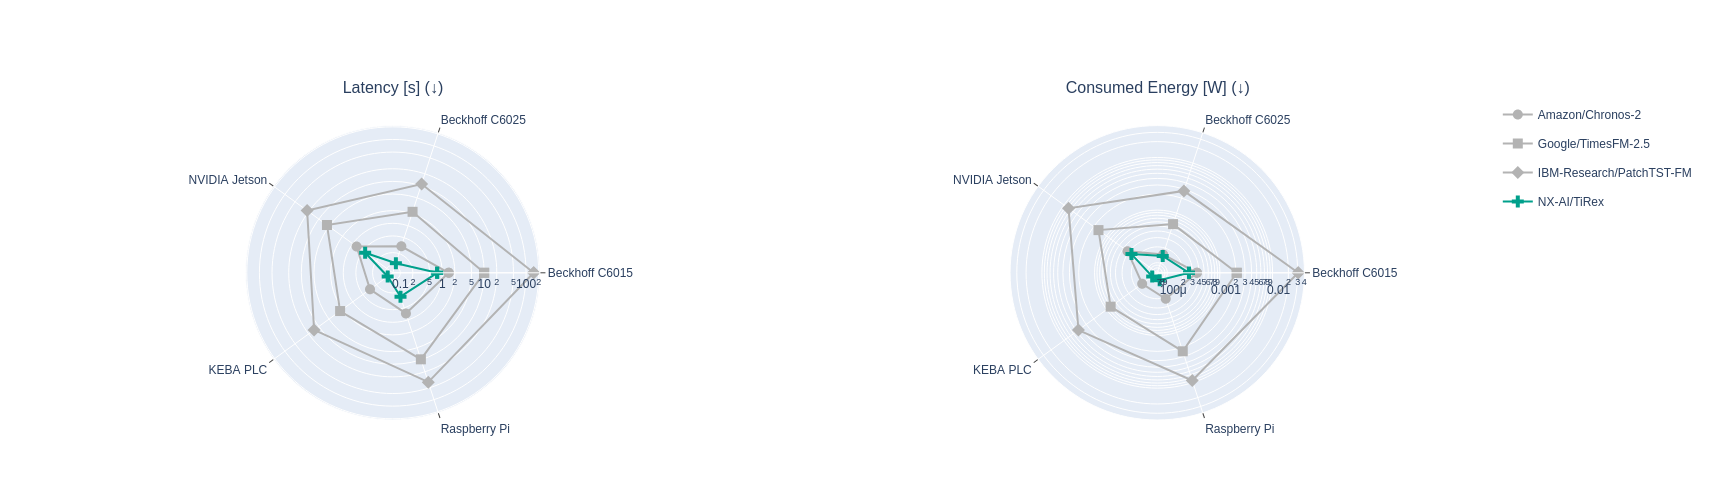

In [28]:
df_edge_selected = df.query("model_name in @selected_models & is_edge_hardware")
model_shape_map = {
    mn: s
    for mn, s in zip(
        sorted(df_edge_selected["model_name"].unique().tolist()), get_symbol_shapes()
    )
}


for hb in [True, False]:
    ms = [c for c in performance_metric_cols if metric_better_map[c] == hb]

    fig = make_subplots(
        rows=1,
        cols=len(ms),
        specs=[[{"type": "polar"}] * len(ms)],
        subplot_titles=[clear_name_map.get(c, c) for c in ms],
    )

    legend_added = defaultdict(lambda: False)
    for i, metric in enumerate(ms):
        for (o, mn), grp in df_edge_selected.groupby(["ours", "model_name"]):
            row, col = 1, i + 1

            # extract data for "circle"
            r = grp[metric].tolist()
            theta = grp["hardware"].tolist()

            # close circle
            r.append(r[0])
            theta.append(theta[0])

            should_show_legends = not legend_added[mn]

            fig.add_trace(
                go.Scatterpolar(
                    r=r,
                    theta=theta,
                    mode="lines+markers",
                    name=mn,
                    marker=dict(
                        size=10,
                        symbol=model_shape_map[mn],
                    ),
                    line=dict(
                        color=color_map[o],
                    ),
                    legendgroup=mn,
                    showlegend=should_show_legends,
                ),
                row=row,
                col=col,
            )
            legend_added[mn] = True

            fig.update_polars(
                radialaxis_type="log",
                row=row,
                col=col,
                domain=dict(y=[0, 0.92]),
                angularaxis=dict(
                    ticks="outside",
                ),
            )

    fig.update_layout(
        width=600 * len(ms),
        height=500,
    )
    fig.show()
    save_fig(fig, f"radio_{'-'.join(ms)}")